<a href="https://colab.research.google.com/github/anant29405/anant/blob/main/EDA_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# PHASE 1 - EXPLORATORY DATA ANALYSIS (EDA)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# 1. Load Dataset

url = "https://raw.githubusercontent.com/salemprakash/EDA/main/Data/melb_data.csv"
df = pd.read_csv(url)

print("First 5 Rows")
print(df.head())

print("\nLast 5 Rows")
print(df.tail())

print("\nShape of Dataset:", df.shape)

print("\nColumn Names")
print(df.columns.tolist())

print("\nDataset Information")
df.info()



First 5 Rows
       Suburb           Address  Rooms Type      Price Method SellerG  \
0  Abbotsford      85 Turner St      2    h  1480000.0      S  Biggin   
1  Abbotsford   25 Bloomburg St      2    h  1035000.0      S  Biggin   
2  Abbotsford      5 Charles St      3    h  1465000.0     SP  Biggin   
3  Abbotsford  40 Federation La      3    h   850000.0     PI  Biggin   
4  Abbotsford       55a Park St      4    h  1600000.0     VB  Nelson   

        Date  Distance  Postcode  ...  Bathroom  Car  Landsize  BuildingArea  \
0  3/12/2016       2.5    3067.0  ...       1.0  1.0     202.0           NaN   
1  4/02/2016       2.5    3067.0  ...       1.0  0.0     156.0          79.0   
2  4/03/2017       2.5    3067.0  ...       2.0  0.0     134.0         150.0   
3  4/03/2017       2.5    3067.0  ...       2.0  1.0      94.0           NaN   
4  4/06/2016       2.5    3067.0  ...       1.0  2.0     120.0         142.0   

   YearBuilt  CouncilArea Lattitude  Longtitude             Regionn

In [ ]:
# 2. Basic Statistical Analysis

print("\nStatistical Summary")
print(df.describe())

print("\nCategorical Summary")
print(df.describe(include='object'))

print("\nMissing Values")
print(df.isnull().sum())

print("\nUnique Values")
print(df.nunique())




Statistical Summary
              Rooms         Price      Distance      Postcode      Bedroom2  \
count  13580.000000  1.358000e+04  13580.000000  13580.000000  13580.000000   
mean       2.937997  1.075684e+06     10.137776   3105.301915      2.914728   
std        0.955748  6.393107e+05      5.868725     90.676964      0.965921   
min        1.000000  8.500000e+04      0.000000   3000.000000      0.000000   
25%        2.000000  6.500000e+05      6.100000   3044.000000      2.000000   
50%        3.000000  9.030000e+05      9.200000   3084.000000      3.000000   
75%        3.000000  1.330000e+06     13.000000   3148.000000      3.000000   
max       10.000000  9.000000e+06     48.100000   3977.000000     20.000000   

           Bathroom           Car       Landsize  BuildingArea    YearBuilt  \
count  13580.000000  13518.000000   13580.000000   7130.000000  8205.000000   
mean       1.534242      1.610075     558.416127    151.967650  1964.684217   
std        0.691712      0.962

In [ ]:
# 3. Handle Missing Values

# Numerical columns
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Categorical columns
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing Values After Handling")
print(df.isnull().sum())




Missing Values After Handling
Suburb           0
Address          0
Rooms            0
Type             0
Price            0
Method           0
SellerG          0
Date             0
Distance         0
Postcode         0
Bedroom2         0
Bathroom         0
Car              0
Landsize         0
BuildingArea     0
YearBuilt        0
CouncilArea      0
Lattitude        0
Longtitude       0
Regionname       0
Propertycount    0
dtype: int64


In [ ]:
# 4. Data Cleaning

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Remove leading/trailing spaces in column names
df.columns = df.columns.str.strip()

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

print("\nShape After Cleaning:", df.shape)




Shape After Cleaning: (13580, 21)


In [ ]:
# 5. Data Transformation

# Label Encoding categorical variables

encoder = LabelEncoder()

for col in cat_cols:
    df[col] = encoder.fit_transform(df[col].astype(str))

# Normalize Price
scaler = MinMaxScaler()
df[['Price']] = scaler.fit_transform(df[['Price']])

print("\nTransformed Dataset")
print(df.head())




Transformed Dataset
   Suburb  Address  Rooms  Type     Price  Method  SellerG  Date  Distance  \
0       0    12794      2     0  0.156478       1       23    29       2.5   
1       0     5943      2     0  0.106562       1       23     1       2.5   
2       0     9814      3     0  0.154795       3       23    33       2.5   
3       0     9004      3     0  0.085810       0       23    33       2.5   
4       0    10589      4     0  0.169938       4      155     8       2.5   

   Postcode  ...  Bathroom  Car  Landsize  BuildingArea  YearBuilt  \
0    3067.0  ...       1.0  1.0     202.0         126.0     1970.0   
1    3067.0  ...       1.0  0.0     156.0          79.0     1900.0   
2    3067.0  ...       2.0  0.0     134.0         150.0     1900.0   
3    3067.0  ...       2.0  1.0      94.0         126.0     1970.0   
4    3067.0  ...       1.0  2.0     120.0         142.0     2014.0   

   CouncilArea  Lattitude  Longtitude  Regionname  Propertycount  
0           31   -37.7

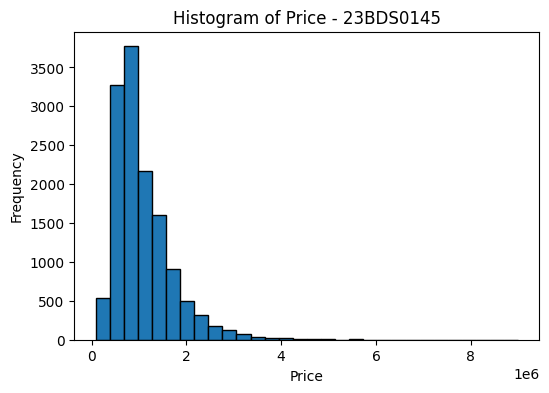

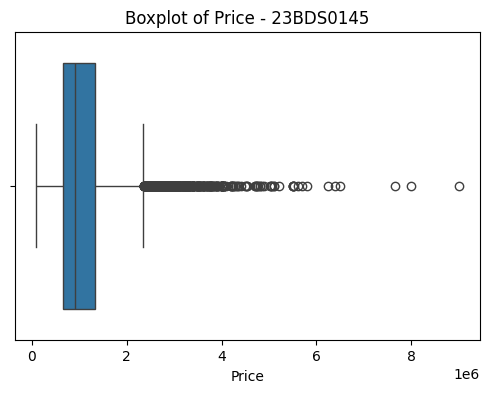

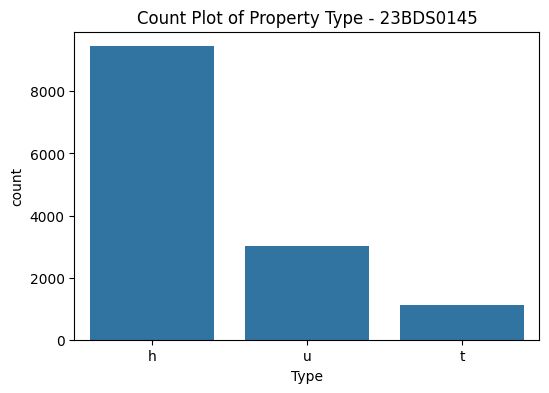

In [31]:
# 6. Univariate Analysis (3 Visualizations)

# Histogram
plt.figure(figsize=(6,4))
plt.hist(df['Price'], bins=30, edgecolor='black')
plt.title("Histogram of Price - 23BDS0145")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

# Boxplot
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Price'])
plt.title("Boxplot of Price - 23BDS0145")
plt.show()

# Count Plot
plt.figure(figsize=(6,4))
sns.countplot(x=df['Type'])
plt.title("Count Plot of Property Type - 23BDS0145")
plt.show()



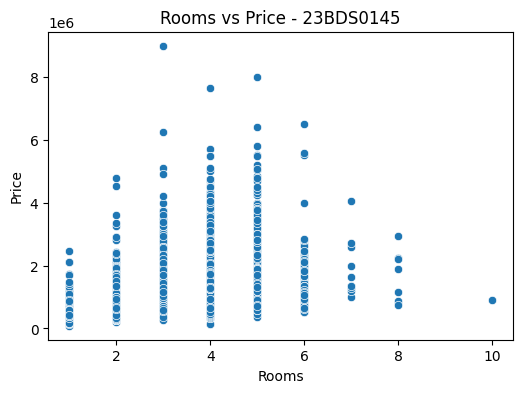

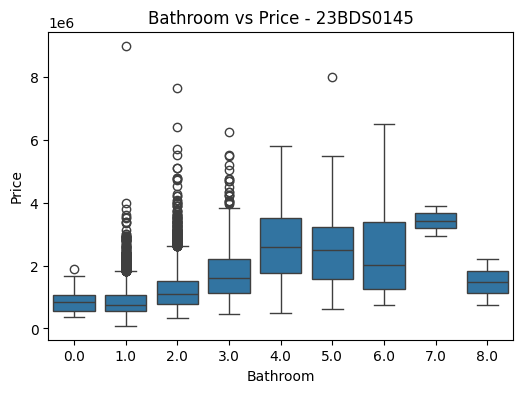

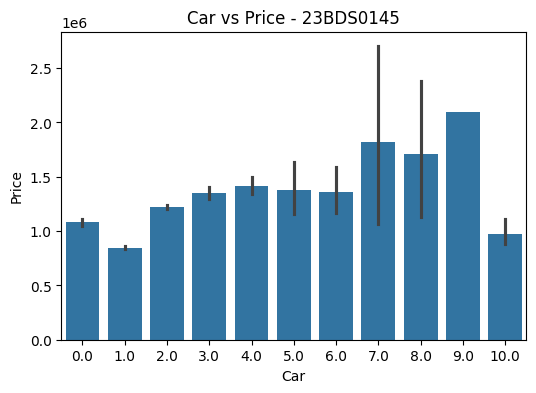

In [30]:
# 7. Bivariate Analysis (3 Visualizations)

# Scatter Plot
plt.figure(figsize=(6,4))
sns.scatterplot(x='Rooms', y='Price', data=df)
plt.title("Rooms vs Price - 23BDS0145")
plt.show()

# Box Plot
plt.figure(figsize=(6,4))
sns.boxplot(x='Bathroom', y='Price', data=df)
plt.title("Bathroom vs Price - 23BDS0145")
plt.show()

# Bar Plot
plt.figure(figsize=(6,4))
sns.barplot(x='Car', y='Price', data=df)
plt.title("Car vs Price - 23BDS0145")
plt.show()



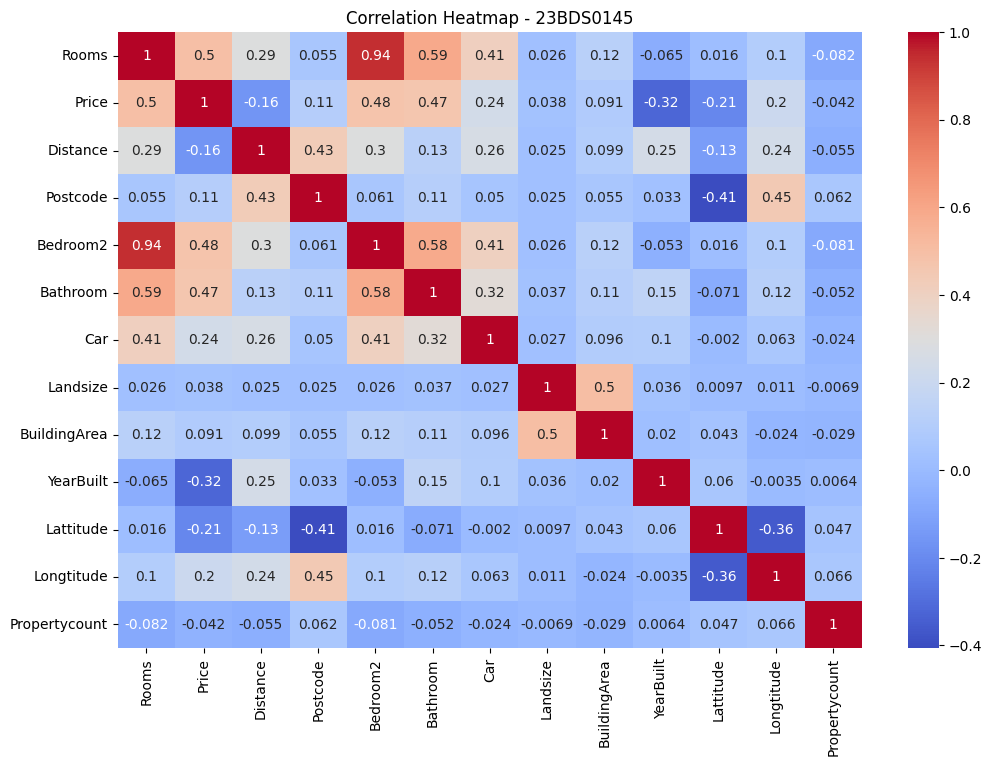

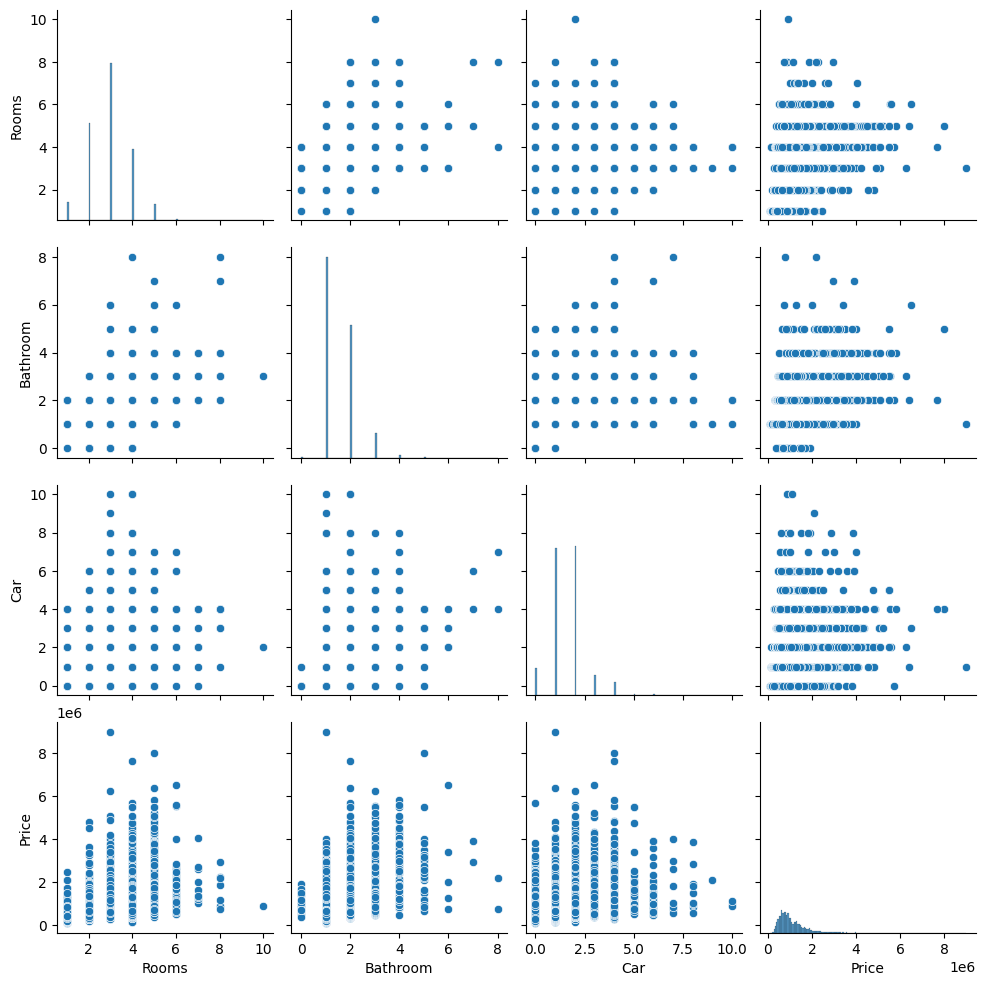

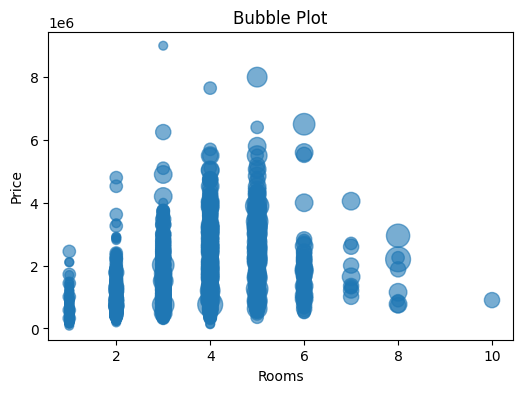

In [29]:
# 8. Multivariate Analysis (3 Visualizations)

# Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap - 23BDS0145")
plt.show()

# Pair Plot
sns.pairplot(df[['Rooms','Bathroom','Car','Price']])
plt.show()

# Bubble Plot
plt.figure(figsize=(6,4))
plt.scatter(df['Rooms'], df['Price'],
            s=df['Bathroom']*40,
            alpha=0.6)

plt.xlabel("Rooms")
plt.ylabel("Price")
plt.title("Bubble Plot")
plt.show()



In [ ]:
# Final Output

print("\nFinal Dataset Shape:", df.shape)

print("\nFirst Five Rows of Final Dataset")
print(df.head())


Final Dataset Shape: (13580, 21)

First Five Rows of Final Dataset
   Suburb  Address  Rooms  Type     Price  Method  SellerG  Date  Distance  \
0       0    12794      2     0  0.156478       1       23    29       2.5   
1       0     5943      2     0  0.106562       1       23     1       2.5   
2       0     9814      3     0  0.154795       3       23    33       2.5   
3       0     9004      3     0  0.085810       0       23    33       2.5   
4       0    10589      4     0  0.169938       4      155     8       2.5   

   Postcode  ...  Bathroom  Car  Landsize  BuildingArea  YearBuilt  \
0    3067.0  ...       1.0  1.0     202.0         126.0     1970.0   
1    3067.0  ...       1.0  0.0     156.0          79.0     1900.0   
2    3067.0  ...       2.0  0.0     134.0         150.0     1900.0   
3    3067.0  ...       2.0  1.0      94.0         126.0     1970.0   
4    3067.0  ...       1.0  2.0     120.0         142.0     2014.0   

   CouncilArea  Lattitude  Longtitude  Reg

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

--- 1D Summary Statistics (Melbourne Housing) ---
                       Mean    Median        Std Dev       IQR  Skewness  \
Rooms          2.943320e+00       3.0       0.953693       1.0  0.369459   
Price          1.078301e+06  905000.0  640148.739869  681000.0  2.239966   
Distance       1.016053e+01       9.2       5.819171       6.8  1.642910   
Landsize       4.415904e+02     431.0     354.382761     476.0  1.684184   
Propertycount  7.447134e+03    6543.0    4374.787467    5951.0  1.074494   

               Kurtosis  
Rooms          0.790978  
Price          9.883536  
Distance       5.045599  
Landsize       7.098520  
Propertycount  1.241170  


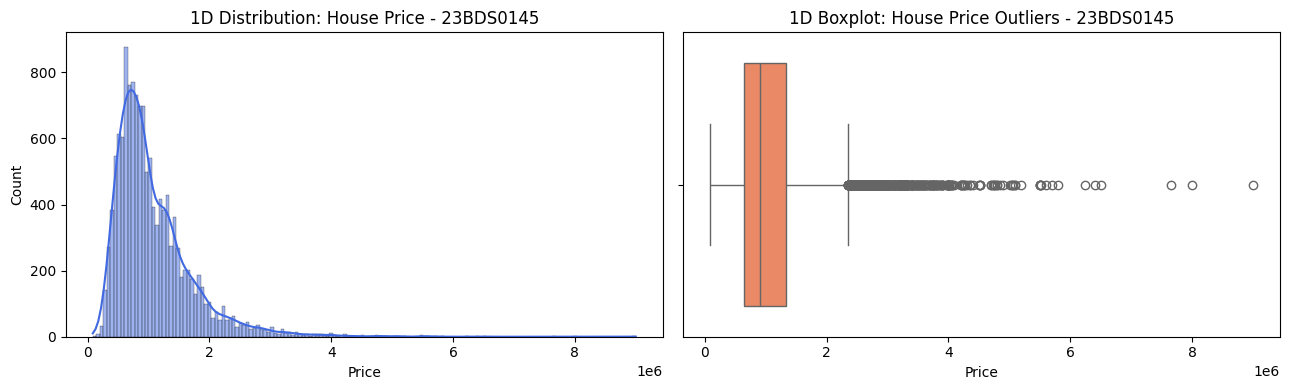

In [28]:
#Phase 2

# Select key numeric housing features and clean missing rows
features = ['Rooms', 'Price', 'Distance', 'Landsize', 'Propertycount']
housing_num = df[features].dropna()

# Remove extreme outliers in Landsize for cleaner analysis
housing_num = housing_num[housing_num['Landsize'] < housing_num['Landsize'].quantile(0.99)]

# 1D Summary Statistics
summary_1d = pd.DataFrame({
    'Mean': housing_num.mean(),
    'Median': housing_num.median(),
    'Std Dev': housing_num.std(),
    'IQR': housing_num.quantile(0.75) - housing_num.quantile(0.25),
    'Skewness': housing_num.skew(),
    'Kurtosis': housing_num.kurtosis()
})
print("--- 1D Summary Statistics (Melbourne Housing) ---")
print(summary_1d)

# 1D Visualization: Price distribution & boxplot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(housing_num['Price'], kde=True, ax=axes[0], color='royalblue')
axes[0].set_title('1D Distribution: House Price - 23BDS0145')

sns.boxplot(x=housing_num['Price'], ax=axes[1], color='coral')
axes[1].set_title('1D Boxplot: House Price Outliers - 23BDS0145')
plt.tight_layout()
plt.show()

--- 2D Analysis: Distance vs. Price ---
Covariance:  -630,597.92
Correlation: -0.1693


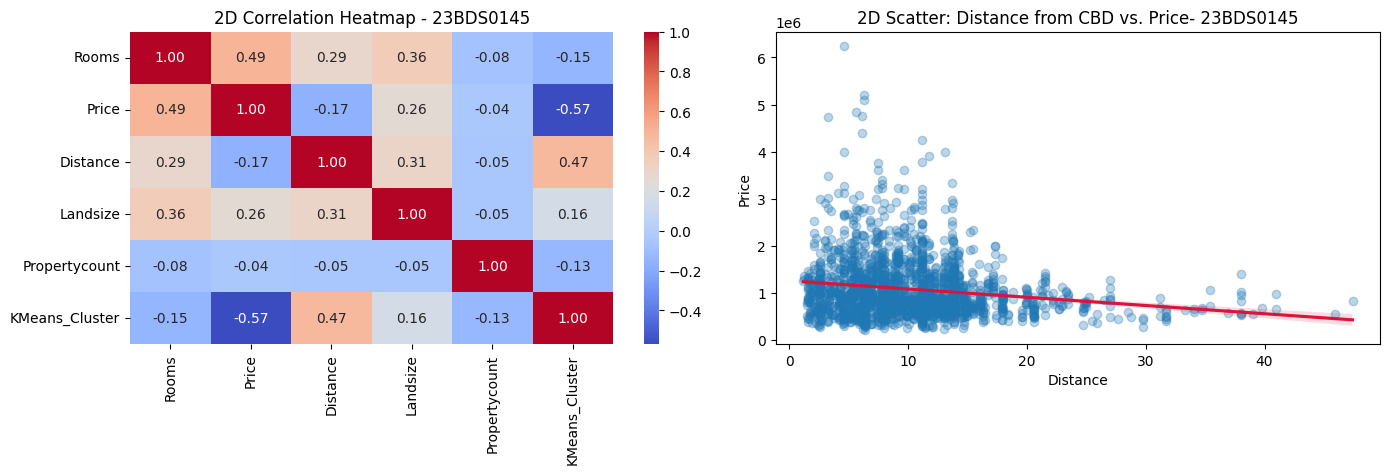

In [26]:
# Covariance & Pearson Correlation between Distance and Price
cov_dist_price = housing_num['Distance'].cov(housing_num['Price'])
corr_dist_price = housing_num['Distance'].corr(housing_num['Price'])

print("--- 2D Analysis: Distance vs. Price ---")
print(f"Covariance:  {cov_dist_price:,.2f}")
print(f"Correlation: {corr_dist_price:.4f}")

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlation Heatmap
sns.heatmap(housing_num.corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=axes[0])
axes[0].set_title("2D Correlation Heatmap - 23BDS0145")

# Scatter with linear regression trend
sns.regplot(
    data=housing_num.sample(2000, random_state=42),
    x='Distance',
    y='Price',
    scatter_kws={'alpha': 0.3},
    line_kws={'color': 'crimson'},
    ax=axes[1]
)
axes[1].set_title("2D Scatter: Distance from CBD vs. Price- 23BDS0145")

plt.tight_layout()
plt.show()

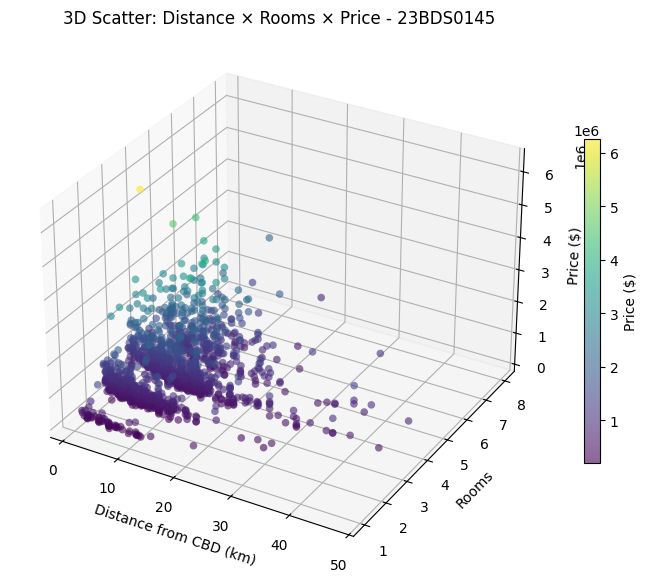

In [24]:


# Sample points for a clear 3D projection
sample_3d = housing_num.sample(1500, random_state=42)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

p = ax.scatter(
    sample_3d['Distance'],
    sample_3d['Rooms'],
    sample_3d['Price'],
    c=sample_3d['Price'],
    cmap='viridis',
    alpha=0.6,
    s=30,
    edgecolor='none'
)

ax.set_xlabel('Distance from CBD (km)')
ax.set_ylabel('Rooms')
ax.set_zlabel('Price ($)')
ax.set_title('3D Scatter: Distance × Rooms × Price - 23BDS0145')
fig.colorbar(p, ax=ax, label='Price ($)', shrink=0.6)

plt.show()

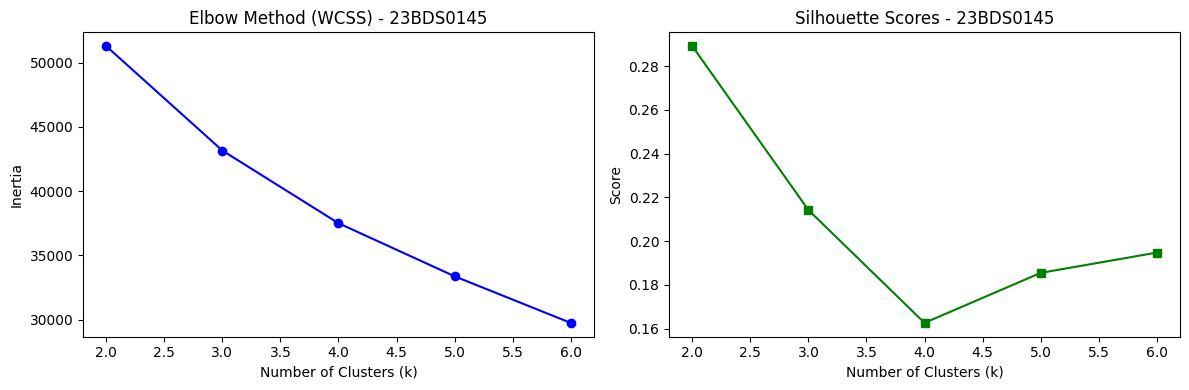

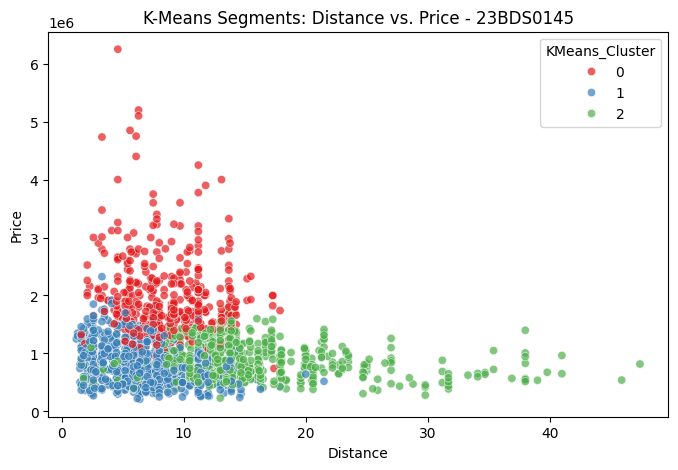

In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# Standardize numeric features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(housing_num[features])

# Evaluate optimal k using Elbow Method & Silhouette Score
k_range = range(2, 7)
wcss = []
sil_scores = []
X_sub = X_scaled[:2500]  # Subset for fast silhouette computation

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X_sub, labels[:2500]))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(k_range, wcss, marker='o', color='b')
ax1.set_title("Elbow Method (WCSS) - 23BDS0145")
ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("Inertia")

ax2.plot(k_range, sil_scores, marker='s', color='g')
ax2.set_title("Silhouette Scores - 23BDS0145")
ax2.set_xlabel("Number of Clusters (k)")
ax2.set_ylabel("Score")
plt.tight_layout()
plt.show()

# Fit K-Means with chosen k=3
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
housing_num['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

# Plot Clusters
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=housing_num.sample(2000, random_state=42),
    x='Distance',
    y='Price',
    hue='KMeans_Cluster',
    palette='Set1',
    alpha=0.7
)
plt.title("K-Means Segments: Distance vs. Price - 23BDS0145")
plt.show()

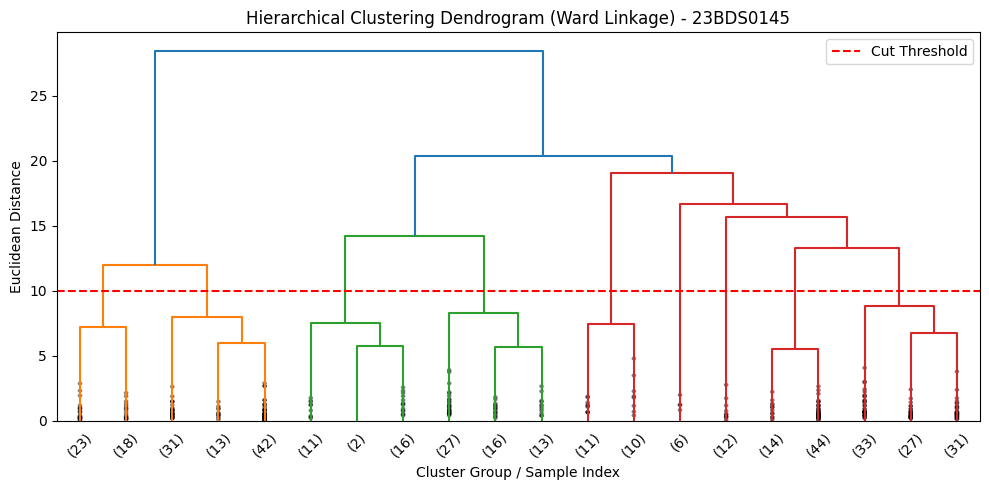

Hierarchical Cluster Distribution ---
Hierarchical_Cluster
3    188
1    127
2     85
Name: count, dtype: int64


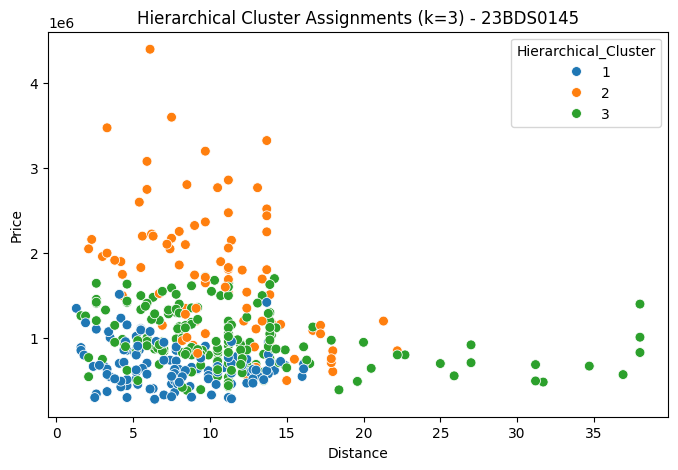

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import fcluster

features = ['Rooms', 'Price', 'Distance', 'Landsize', 'Propertycount']

# 1. Take a representative sample (400 records) to keep the dendrogram clean and performant
sample_hier = housing_num.sample(400, random_state=42).copy()
scaler = StandardScaler()
X_hier_scaled = scaler.fit_transform(sample_hier[features])

# 2. Compute Ward Linkage matrix
linkage_matrix = sch.linkage(X_hier_scaled, method='ward')

# 3. Plot Dendrogram
plt.figure(figsize=(10, 5))
sch.dendrogram(
    linkage_matrix,
    truncate_mode='lastp',
    p=20,
    leaf_rotation=45.,
    leaf_font_size=10.,
    show_contracted=True
)
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage) - 23BDS0145")
plt.xlabel("Cluster Group / Sample Index")
plt.ylabel("Euclidean Distance")
plt.axhline(y=10, color='r', linestyle='--', label='Cut Threshold')
plt.legend()
plt.tight_layout()
plt.show()

# 4. Form clusters from the hierarchy (k=3)
sample_hier['Hierarchical_Cluster'] = fcluster(linkage_matrix, t=3, criterion='maxclust')

print("Hierarchical Cluster Distribution ---")
print(sample_hier['Hierarchical_Cluster'].value_counts())

# 5. Scatter plot of hierarchical clusters
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=sample_hier,
    x='Distance',
    y='Price',
    hue='Hierarchical_Cluster',
    palette='tab10',
    s=50
)
plt.title("Hierarchical Cluster Assignments (k=3) - 23BDS0145")
plt.show()